<h1 style="color:pink;">Entrenamiento de CNN con modificaciones en su función de pérdida.</h1>
<p>Valentina Arce España</p>
<p>Versión V6 corregida — Febrero 2026</p>

Entrenamos con la función $L_{total} = L_{MSE} + \lambda_1 L_{NASA} + \lambda_2 \frac{1}{m-1}\sum dh^2$.

**Correcciones aplicadas respecto a V5:**
1. `create_windows` ahora también devuelve el `unit_id` de cada ventana.
2. `dh` se calcula **solo entre predicciones del mismo motor** (máscara `same_unit_mask`).
3. Bloque de diagnóstico para estimar la magnitud de cada término antes de elegir lambdas.
4. El loop imprime cada componente por separado para monitorear el entrenamiento.

In [1]:
import sys
print(sys.executable)

/Users/mac/Documents/Tendencias/torch-env/bin/python


In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

filename    = 'N-CMAPSS_DS08a-009.h5'
WINDOW_SIZE = 50
BATCH_SIZE  = 512
EPOCHS      = 15
TRAIN_RATIO = 0.3   # same as your original working version
WINDOW_STEP = 10

def load_data(filepath):
    with h5py.File(filepath, 'r') as hdf:
        W_dev    = np.array(hdf.get('W_dev'))
        X_s_dev  = np.array(hdf.get('X_s_dev'))
        X_v_dev  = np.array(hdf.get('X_v_dev'))
        Y_dev    = np.array(hdf.get('Y_dev'))
        A_dev    = np.array(hdf.get('A_dev'))
        W_test   = np.array(hdf.get('W_test'))
        X_s_test = np.array(hdf.get('X_s_test'))
        X_v_test = np.array(hdf.get('X_v_test'))
        Y_test   = np.array(hdf.get('Y_test'))
        A_test   = np.array(hdf.get('A_test'))
        A_var    = list(np.array(hdf.get('A_var')).astype('U20'))
    return (W_dev, X_s_dev, X_v_dev, Y_dev, A_dev), \
           (W_test, X_s_test, X_v_test, Y_test, A_test), A_var

print('Cargando datos...')
(train_W, train_Xs, train_Xv, train_Y, train_A), \
(test_W,  test_Xs,  test_Xv,  test_Y,  test_A), A_var = load_data(filename)

train_units  = np.unique(train_A[:, 0])
n_units_keep = int(len(train_units) * TRAIN_RATIO)
keep_units   = train_units[:n_units_keep]
print(f'Usando {n_units_keep} de {len(train_units)} motores de entrenamiento.')

mask_train = np.isin(train_A[:, 0], keep_units)
train_W    = train_W[mask_train];  train_Xs = train_Xs[mask_train]
train_Xv   = train_Xv[mask_train]; train_Y  = train_Y[mask_train]
train_A    = train_A[mask_train]

X_train = np.concatenate((train_W, train_Xs, train_Xv), axis=1)
X_test  = np.concatenate((test_W,  test_Xs,  test_Xv),  axis=1)

# ── Restored to (-1, 1): this is what your original working CNN used.
# Do NOT change this — it was not the source of the zero-prediction bug.
scaler         = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f'X_train shape: {X_train_scaled.shape}')

# ── Y targets stay in RAW CYCLES — no normalization.
# Normalizing Y to [0,1] reduces the MSE gradient by a factor of
# RUL_MAX^2 (~5929×), making learning extremely slow with the same lr.
# The NASA loss will handle raw cycle values directly (see loss cell).
RUL_MAX = float(np.max(train_Y))   # kept for NASA loss scaling only
print(f'RUL range: [0, {RUL_MAX:.1f}] ciclos (targets sin normalizar)')

def create_windows(X, y, A, window_size, step=1, unit_col_index=0):
    unique_units = np.unique(A[:, unit_col_index])
    X_windows, y_windows, unit_ids = [], [], []
    for unit in unique_units:
        idx    = np.where(A[:, unit_col_index] == unit)[0]
        unit_X = X[idx, :]
        unit_y = y[idx]
        n      = len(unit_X)
        if n < window_size:
            continue
        for i in range(0, n - window_size + 1, step):
            X_windows.append(unit_X[i: i + window_size, :])
            y_windows.append(unit_y[i + window_size - 1])
            unit_ids.append(unit)
    return np.array(X_windows), np.array(y_windows), np.array(unit_ids)

print(f'Generando ventanas (Step={WINDOW_STEP})...')
X_train_w, y_train_w, unit_ids_train = create_windows(
    X_train_scaled, train_Y, train_A, WINDOW_SIZE, step=WINDOW_STEP)
X_test_w, y_test_w, unit_ids_test = create_windows(
    X_test_scaled, test_Y, test_A, WINDOW_SIZE, step=10)

print(f'Input Shape Train: {X_train_w.shape}')
print(f'Input Shape Test:  {X_test_w.shape}')
print(f'y_train range: [{y_train_w.min():.1f}, {y_train_w.max():.1f}] ciclos')


Cargando datos...
Usando 2 de 9 motores de entrenamiento.
X_train shape: (1060535, 32)
RUL range: [0, 71.0] ciclos (targets sin normalizar)
Generando ventanas (Step=10)...
Input Shape Train: (106045, 50, 32)
Input Shape Test:  (372274, 50, 32)
y_train range: [0.0, 71.0] ciclos


## Función de pérdida corregida

El cambio más importante está en `temporal_smoothness`: se construye una máscara
`same_unit_mask` que es `True` **solo cuando dos predicciones consecutivas dentro
del batch pertenecen al mismo motor**. Los pares que cruzan la frontera entre motores
quedan excluidos y no contaminan el gradiente de suavidad.

In [3]:
import torch
import torch.nn as nn

class PhysicsInformedRULLoss(nn.Module):
    """
    L_total = L_MSE + lambda1 * L_NASA + lambda2 * L_dh

    ALL terms operate on RAW CYCLE values (not normalized).
    This keeps the NASA constants (13, 10) valid by design, and
    keeps the MSE gradient in the same scale as your original CNN.

    L_NASA is divided by RUL_MAX so its magnitude stays comparable
    to L_MSE (otherwise exp(77/10)~2980 would dwarf MSE).

    L_dh operates on raw cycle differences — dh in units of cycles/step.
    """
    def __init__(self, rul_max, lambda1=0.1, lambda2=0.01):
        super().__init__()
        self.mse     = nn.MSELoss()
        self.rul_max = rul_max
        self.lambda1 = lambda1
        self.lambda2 = lambda2

    def nasa_score(self, y_pred, y_true):
        """
        Raw-cycle NASA scoring function.
        d < 0 → late prediction (smaller penalty)
        d > 0 → early prediction (larger penalty — we prefer to predict
                RUL lower than actual, i.e. conservative)
        Divided by rul_max to bring magnitude in line with L_MSE.
        """
        d = y_pred - y_true   # raw cycles
        score = torch.where(
            d < 0,
            torch.exp(-d / 13.0) - 1,
            torch.exp( d / 10.0) - 1
        )
        return torch.mean(score) / self.rul_max

    def temporal_smoothness(self, y_pred, unit_ids):
        """
        (1/(m-1)) * sum(dh^2), same-engine pairs only.
        dh is in raw cycle units so its scale matches the MSE.
        """
        if y_pred.shape[0] < 2:
            return torch.tensor(0.0, device=y_pred.device)
        dh             = y_pred[1:] - y_pred[:-1]
        same_unit_mask = (unit_ids[1:] == unit_ids[:-1])
        if same_unit_mask.sum() == 0:
            return torch.tensor(0.0, device=y_pred.device)
        return torch.mean(dh[same_unit_mask] ** 2)

    def forward(self, y_pred, y_true, unit_ids):
        loss_mse  = self.mse(y_pred, y_true)
        loss_nasa = self.nasa_score(y_pred, y_true)
        loss_dh   = self.temporal_smoothness(y_pred.squeeze(), unit_ids)
        loss_total = loss_mse + self.lambda1 * loss_nasa + self.lambda2 * loss_dh
        components = {
            'mse':   loss_mse.item(),
            'nasa':  loss_nasa.item(),
            'dh':    loss_dh.item(),
            'total': loss_total.item()
        }
        return loss_total, components


In [4]:
class CNN_RUL(nn.Module):
    """
    Restored to the original architecture that produced good predictions.
    BatchNorm was removed — with shuffle=False and sequential degradation
    data it can normalize away exactly the degradation signal we want to
    detect, since batch statistics change systematically along the timeline.
    Output is linear (no Sigmoid, no BatchNorm). Only change from your
    original working CNN: we kept Dropout(0.3) before fc1.
    """
    def __init__(self, num_features=32, window_size=50):
        super().__init__()
        self.conv1 = nn.Conv1d(num_features, 32,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32,  64,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(64,  128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(128, 64,  kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(64,  32,  kernel_size=3, padding=1)
        self.relu    = nn.ReLU()
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p=0.3)
        self.fc1 = nn.Linear(32 * window_size, 128)
        self.fc2 = nn.Linear(128, 1)  # linear output, raw cycle scale

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.relu(self.conv5(x))
        x = self.flatten(x)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)


## DataLoader corregido

`shuffle=False` sigue siendo **obligatorio** para preservar el orden temporal.
Ahora añadimos `unit_ids_tensor` al dataset para que la función de pérdida
sepa a qué motor pertenece cada muestra y pueda enmascarar las transiciones.

In [5]:
from torch.utils.data import TensorDataset, DataLoader

X_tensor        = torch.tensor(X_train_w,       dtype=torch.float32)
y_tensor        = torch.tensor(y_train_w,       dtype=torch.float32).view(-1, 1)
unit_ids_tensor = torch.tensor(unit_ids_train,  dtype=torch.float32)  # float para TensorDataset

train_dataset = TensorDataset(X_tensor, y_tensor, unit_ids_tensor)

# shuffle=False es OBLIGATORIO: el orden temporal de las ventanas debe
# mantenerse para que dh[i] = h[i+1] - h[i] tenga significado físico.
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False)

print(f'Total batches por época: {len(train_loader)}')
print(f'Motores en entrenamiento: {np.unique(unit_ids_train)}')


Total batches por época: 415
Motores en entrenamiento: [1. 2.]


## Diagnóstico de escala de pérdidas

Antes de fijar lambda1 y lambda2, este bloque estima la magnitud de cada término
con el modelo sin entrenar (pesos aleatorios). Esto te da una idea de si los tres
términos están en la misma escala.

**Regla práctica:** ajusta los lambdas para que `lambda_i * L_i ≈ L_MSE` en la
primera época. Si `dh` es 10× mayor que MSE, prueba `lambda2 = 0.1` en vez de `0.5`.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

_model_diag = CNN_RUL().to(device)
_crit_diag  = PhysicsInformedRULLoss(rul_max=RUL_MAX, lambda1=1.0, lambda2=1.0)

_model_diag.eval()
with torch.no_grad():
    _X, _y, _uid = next(iter(train_loader))
    _X   = _X.to(device)
    _y   = _y.to(device)
    _uid = _uid.long().to(device)
    _, diag_comps = _crit_diag(_model_diag(_X), _y, _uid)

print('=== Magnitudes sin entrenar (lambda1=lambda2=1, raw cycles) ===')
print(f'  L_MSE  = {diag_comps["mse"]:.2f}  ← escala de ciclos^2')
print(f'  L_NASA = {diag_comps["nasa"]:.4f}  ← normalizado por RUL_MAX')
print(f'  L_dh   = {diag_comps["dh"]:.4f}')
print()
if diag_comps['nasa'] > 0 and diag_comps['dh'] > 0:
    sl1 = round(diag_comps['mse'] / diag_comps['nasa'], 4)
    sl2 = round(diag_comps['mse'] / diag_comps['dh'],   4)
    print(f'Sugerencia: lambda1={sl1}, lambda2={sl2}')


Usando dispositivo: cpu
=== Magnitudes sin entrenar (lambda1=lambda2=1, raw cycles) ===
  L_MSE  = 5047.66  ← escala de ciclos^2
  L_NASA = 3.3142  ← normalizado por RUL_MAX
  L_dh   = 0.0000

Sugerencia: lambda1=1523.026, lambda2=2366739252730.7437


## Bucle de entrenamiento

Ajusta `LAMBDA1` y `LAMBDA2` con los valores del diagnóstico anterior.
El loop imprime cada componente por época para que puedas detectar si
algún término domina o desaparece.

In [7]:
LAMBDA1 = 0.1
LAMBDA2 = 0.01

model     = CNN_RUL().to(device)
criterion = PhysicsInformedRULLoss(rul_max=RUL_MAX, lambda1=LAMBDA1, lambda2=LAMBDA2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = []

for epoch in range(EPOCHS):
    model.train()
    accum = {'mse': 0.0, 'nasa': 0.0, 'dh': 0.0, 'total': 0.0}

    for inputs, targets, uid in train_loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)
        uid     = uid.long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss, comps = criterion(outputs, targets, uid)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        for k in accum:
            accum[k] += comps[k]

    n   = len(train_loader)
    avg = {k: v / n for k, v in accum.items()}
    history.append(avg)
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Total={avg['total']:.4f} | "
        f"MSE={avg['mse']:.4f} | "
        f"NASA={avg['nasa']:.5f} | "
        f"dh={avg['dh']:.4f}"
    )

print('Entrenamiento completado.')


Epoch 01/15 | Total=333.2499 | MSE=331.6372 | NASA=13.61260 | dh=25.1444
Epoch 02/15 | Total=448.6591 | MSE=447.2851 | NASA=7.46879 | dh=62.7158
Epoch 03/15 | Total=437.6030 | MSE=437.1562 | NASA=0.22608 | dh=42.4230
Epoch 04/15 | Total=522.1633 | MSE=521.6887 | NASA=1.05471 | dh=36.9101
Epoch 05/15 | Total=400.3134 | MSE=399.9123 | NASA=0.15542 | dh=38.5557
Epoch 06/15 | Total=573.4516 | MSE=572.6778 | NASA=2.80251 | dh=49.3533
Epoch 07/15 | Total=605.0159 | MSE=558.1534 | NASA=443.71408 | dh=249.1048
Epoch 08/15 | Total=569.3574 | MSE=566.8656 | NASA=0.68193 | dh=242.3537
Epoch 09/15 | Total=321.4032 | MSE=321.1251 | NASA=0.11749 | dh=26.6373
Epoch 10/15 | Total=459.9949 | MSE=459.5597 | NASA=0.25241 | dh=40.9920
Epoch 11/15 | Total=371.7748 | MSE=371.2942 | NASA=0.18983 | dh=46.1593
Epoch 12/15 | Total=436.0505 | MSE=435.5289 | NASA=0.16745 | dh=50.4908
Epoch 13/15 | Total=408.0363 | MSE=407.0360 | NASA=0.16970 | dh=98.3294
Epoch 14/15 | Total=446.8614 | MSE=446.3002 | NASA=0.29975 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key, title, color in zip(
    axes,
    ['mse', 'nasa', 'dh'],
    ['L_MSE', 'L_NASA (asimétrica)', 'L_dh (suavidad temporal)'],
    ['steelblue', 'tomato', 'seagreen']
):
    vals = [h[key] for h in history]
    ax.plot(range(1, len(vals)+1), vals, marker='o', color=color, linewidth=2)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida promedio')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Evolución por componente de pérdida', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Señal de alerta: si dh cae a 0 en la primera época, lambda2 es demasiado alto.
# Si nasa sube, es posible que lambda1 esté mal calibrado.


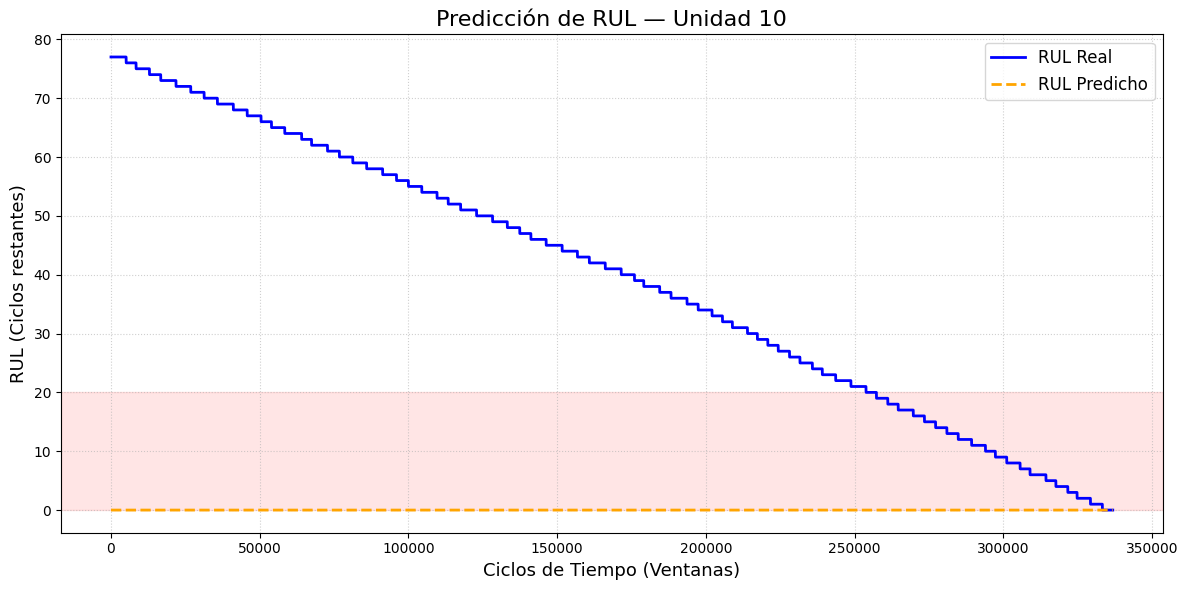

Pred range: [0.0, 0.0]  True range: [0.0, 77.0]


In [8]:
from torch.utils.data import DataLoader, TensorDataset

def comparar_resultados_motores(unit_id):
    idx = np.where(test_A[:, 0] == unit_id)[0]
    if len(idx) == 0:
        print(f'Motor {unit_id} no encontrado en test.')
        return

    unit_X = X_test_scaled[idx, :]
    unit_y = test_Y[idx]
    unit_A = test_A[idx, :]

    X_motor_w, y_motor_w, _ = create_windows(unit_X, unit_y, unit_A, WINDOW_SIZE, step=1)

    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_motor_w, dtype=torch.float32)),
        batch_size=512, shuffle=False
    )

    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for (batch_x,) in test_loader:
            # Output is raw cycles — no inverse transform needed
            out = model(batch_x.to(device))
            out = torch.clamp(out, min=0.0)   # RUL >= 0
            y_pred_list.append(out.cpu().numpy())

    y_pred = np.concatenate(y_pred_list, axis=0)

    plt.figure(figsize=(12, 6))
    plt.plot(y_motor_w, label='RUL Real',     color='blue',   linewidth=2)
    plt.plot(y_pred,    label='RUL Predicho', color='orange', linewidth=2, linestyle='--')
    plt.title(f'Predicción de RUL — Unidad {unit_id}', fontsize=16)
    plt.xlabel('Ciclos de Tiempo (Ventanas)', fontsize=13)
    plt.ylabel('RUL (Ciclos restantes)', fontsize=13)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.axhspan(0, 20, color='red', alpha=0.1)
    plt.tight_layout()
    plt.show()
    print(f'Pred range: [{y_pred.min():.1f}, {y_pred.max():.1f}]  '
          f'True range: [{y_motor_w.min():.1f}, {y_motor_w.max():.1f}]')

comparar_resultados_motores(10)


In [ ]:
# ================================================================
# DIAGNOSTIC: plot a TRAINING engine, not just test engine 10.
# If the training engine curve looks good but test engine doesn't,
# the problem is purely generalization (too few training engines).
# If training engine is also flat, the model isn't learning at all.
# ================================================================

def plot_engine(unit_id, X_scaled, Y_raw, A, label=''):
    idx    = np.where(A[:, 0] == unit_id)[0]
    if len(idx) == 0:
        print(f'Motor {unit_id} no encontrado.')
        return
    unit_X = X_scaled[idx, :]
    unit_y = Y_raw[idx]
    unit_A = A[idx, :]

    X_w, y_w, _ = create_windows(unit_X, unit_y, unit_A, WINDOW_SIZE, step=1)

    loader = DataLoader(
        TensorDataset(torch.tensor(X_w, dtype=torch.float32)),
        batch_size=512, shuffle=False
    )
    model.eval()
    preds = []
    with torch.no_grad():
        for (bx,) in loader:
            out = model(bx.to(device))
            preds.append(out.cpu().numpy())
    y_pred = np.concatenate(preds) * RUL_MAX

    plt.figure(figsize=(12, 5))
    plt.plot(y_w,    label='RUL Real',     color='blue',   linewidth=2)
    plt.plot(y_pred, label='RUL Predicho', color='orange', linewidth=2, linestyle='--')
    plt.title(f'Motor {unit_id} — {label}', fontsize=15)
    plt.xlabel('Ventanas'); plt.ylabel('RUL (ciclos)')
    plt.legend(); plt.grid(True, linestyle=':', alpha=0.6)
    plt.axhspan(0, 20, color='red', alpha=0.1)
    plt.tight_layout(); plt.show()
    print(f'Pred range: [{y_pred.min():.2f}, {y_pred.max():.2f}]  '
          f'True range: [{y_w.min():.2f}, {y_w.max():.2f}]')

# Plot one of the training engines
train_engine_id = int(keep_units[0])
print(f'=== Motor de ENTRENAMIENTO: {train_engine_id} ===')
plot_engine(train_engine_id, X_train_scaled, train_Y, train_A,
            label='ENTRENAMIENTO — ¿aprende en datos que ya vio?')

# Plot test engine 10
print(f'=== Motor de PRUEBA: 10 ===')
plot_engine(10, X_test_scaled, test_Y, test_A,
            label='PRUEBA — ¿generaliza a un motor nuevo?')

print()
print('INTERPRETACIÓN:')
print('  Entrenamiento OK  + Prueba plana  → problema de generalización (necesitas más motores)')
print('  Entrenamiento plano también       → el modelo no está aprendiendo en absoluto')
